In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Opgave 5.1

### (a)

$$
\begin{align*}
(AB^{-1})^{-1}A & = B A^{-1} A \\
 & = B I_{n} \\
 & = B
\end{align*}
$$

### (b)

$$
\begin{align*}
A^{-1} (A^{T}B)^{T} & = A^{-1} B^{T} A
\end{align*}
$$

### (c)

$$
\begin{align*}
(AC)^{-1} (ABA^{-1}) (AC) & = C^{-1} (A^{-1}A) B (A^{-1}A) C \\
 & = C^{-1} I_{n} B I_{n} C \\
 & = C^{-1} B C
\end{align*}
$$

### (d)

$$
\begin{align*}
(A^{-1} B)^{T} A^{T} & = B^{T} (A^{-1})^{T} A^{T} \\
 & = B^{T} (A A^{-1})^{T} \\
 & = B^{T} (I_{n})^{T} \\
 & = B^{T}
\end{align*}
$$

## Opgave 5.2

### (a)

In [2]:
v_0 = np.array([2, 1, -2])[:, np.newaxis]
v_1 = np.array([1, 0, 1])[:, np.newaxis]
v_2 = np.array([1, -4, -1])[:, np.newaxis]

print(np.vdot(v_0, v_1), np.vdot(v_0, v_2), np.vdot(v_1, v_2))

0 0 0


Alle deres indre produkter er 0 så de er ortogonale.

Man kunne også have gjort det med en grammatrix

### (b)

In [3]:
w = np.array((4,5,6))[:, np.newaxis]

x_0 = np.vdot(w, v_0) / (np.linalg.norm(v_0)**2)
x_1 = np.vdot(w, v_1) / (np.linalg.norm(v_1)**2)
x_2 = np.vdot(w, v_2) / (np.linalg.norm(v_2)**2)

w_2 = np.sqrt(x_0**2 * np.linalg.norm(v_0)**2 + x_1**2 * np.linalg.norm(v_1)**2 + x_2**2 * np.linalg.norm(v_2)**2)
print("w =\n", w, "\n")
print("||w||_2 =", w_2)
print("kontrol:", np.linalg.norm(w))

w =
 [[4]
 [5]
 [6]] 

||w||_2 = 8.774964387392123
kontrol: 8.774964387392123


### (c)

In [4]:
A = np.column_stack((v_0 / np.linalg.norm(v_0), v_1 / np.linalg.norm(v_1), v_2 / np.linalg.norm(v_2)))

print(A)

[[ 0.66666667  0.70710678  0.23570226]
 [ 0.33333333  0.         -0.94280904]
 [-0.66666667  0.70710678 -0.23570226]]


### (d)

In [5]:
x_i = np.array((x_0, x_1, x_2))[:, np.newaxis]

print(A.T@w / x_i)

[[3.        ]
 [1.41421356]
 [4.24264069]]


## Opgave 5.3

In [6]:
i = 1000 * 10 * 2 * 200 + 5 * 10 * 2 * 1000
ii = 5 * 200 * 2 * 1000 + 5 * 10 * 2 * 200

print(f"A(BC) bruger {i} flops \n(AB)C bruger {ii} flops")

A(BC) bruger 4100000 flops 
(AB)C bruger 2020000 flops


ii bruger færrest med 2.020.000 flops.

## Opgave 5.4 (åbenbart forkert, men kan ikke finde anden løsning)

$\boxed{\text{D}}$ 501.

De to række-søjleprodukter tæller hver for $2 \cdot 100 = 200$

## Opgave 5.5

In [7]:
A = np.array([  [1, 2, 2], 
                [2, 1, -1], 
                [-1, 2, 1]])
ligning = np.column_stack((A, np.eye(A.shape[0])))

print(ligning)


[[ 1.  2.  2.  1.  0.  0.]
 [ 2.  1. -1.  0.  1.  0.]
 [-1.  2.  1.  0.  0.  1.]]


In [8]:
# Echelon form
# R1 -> R1 - 2R0                        (6 + 6 = 12 flops)
ligning[1] -= 2 * ligning[0]
# R1 -> R1 * 1/-3                       (6 flops)
ligning[1] *= 1 / ligning[1,1]
# R2 -> R2 + R0                         (6 flops)
ligning[2] += ligning[0]
# R2 -> R2 - 2R1                        (6 + 6 = 12 flops)
ligning[2] -= 4 * ligning[1]
# R2 -> R2 * -1/3.66                    (6 flops)
ligning[2] *= 1 / ligning[2,2]

# Backward soemthing sometyhing
# R1 -> R1 - 1.66R2                     (6)
ligning[1] -= ligning[1,2] * ligning[2]
# R0 -> R0 - 2R1                        (6 + 6 = 12 flops)
ligning[0] -= 2 * ligning[1]
# R0 -> R0 - 2R2                        (6 + 6 = 12 flops)
ligning[0] -= 2 * ligning[2]

print(ligning)

A_inv = ligning[:, 3:]
print("\nA inverteret er:\n",A_inv)

[[ 1.          0.          0.          0.27272727  0.18181818 -0.36363636]
 [ 0.          1.          0.         -0.09090909  0.27272727  0.45454545]
 [-0.         -0.          1.          0.45454545 -0.36363636 -0.27272727]]

A inverteret er:
 [[ 0.27272727  0.18181818 -0.36363636]
 [-0.09090909  0.27272727  0.45454545]
 [ 0.45454545 -0.36363636 -0.27272727]]


Noget costsaving man kunne gøre som jeg ikke magter er at tage intervaller når man backpropagator eller hvad det hedder. Med min naive dårlige metode har jeg brugt 72. Med costsavingen kunne man cutte det ned på 70.

Ses der på denne (3x3)-matrix kan det ses at der i værste tilfælde kommer til at være følgende mængde af flops:
$$
3 + (2 \cdot 3 + 3) + (2 \cdot 3 + 2 \cdot 3 + 3) + 3 + (2 \cdot 3) + (3 \cdot 3)
$$

Det kan ses at der dannes et mønster. Det værste tilfælde vil da medbrine at en (nxn)-matrix har følgende flops:
$$
n + (2n + n) + \dots + (2n \cdot n-2 + n) + (2n \cdot n-1 + n) + n + (2n) + \dots + ((n-1) \cdot n) + (n \cdot n)
$$

Hvilket svarer til:
$$
\begin{align*}
    \sum^{n-1}_{i=0} (2n \cdot i + n) + \sum^{n}_{i=1} (i \cdot n) & = \sum^{n-1}_{i=0} (2n \cdot i + n) + \sum^{n-1}_{i=0} ((i+1) \cdot (n)) \\
    & = \sum^{n-1}_{i=0} (2n \cdot i + n + (i+1) \cdot (n-1))
\end{align*}
$$

## Opgave 5.6

### (a)

In [9]:
n = 200

x = np.linspace(0, 2 * np.pi, n)
v0 = np.ones(x.shape)[:, np.newaxis]
v1 = np.sin(x)[:, np.newaxis]
v2 = np.cos(x)[:, np.newaxis]
v3 = np.sin(2*x)[:, np.newaxis]
v4 = np.cos(2*x)[:, np.newaxis]

cos_v0v1 = np.vdot(v0, v1) / (np.linalg.norm(v0) * np.linalg.norm(v1))
cos_v0v2 = np.vdot(v0, v2) / (np.linalg.norm(v0) * np.linalg.norm(v2))
cos_v0v3 = np.vdot(v0, v3) / (np.linalg.norm(v0) * np.linalg.norm(v3))
cos_v0v4 = np.vdot(v0, v4) / (np.linalg.norm(v0) * np.linalg.norm(v4))
cos_v1v2 = np.vdot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
cos_v1v3 = np.vdot(v1, v3) / (np.linalg.norm(v1) * np.linalg.norm(v3))
cos_v1v4 = np.vdot(v1, v4) / (np.linalg.norm(v1) * np.linalg.norm(v4))
cos_v2v3 = np.vdot(v2, v3) / (np.linalg.norm(v2) * np.linalg.norm(v3))
cos_v2v4 = np.vdot(v2, v4) / (np.linalg.norm(v2) * np.linalg.norm(v4))
cos_v3v4 = np.vdot(v3, v4) / (np.linalg.norm(v3) * np.linalg.norm(v4))

print(f"cosinus til vinklen mellem v0 og v1 er {cos_v0v1}")
print(f"cosinus til vinklen mellem v0 og v2 er {cos_v0v2}")
print(f"cosinus til vinklen mellem v0 og v3 er {cos_v0v3}")
print(f"cosinus til vinklen mellem v0 og v4 er {cos_v0v4}")
print(f"cosinus til vinklen mellem v1 og v2 er {cos_v1v2}")
print(f"cosinus til vinklen mellem v1 og v3 er {cos_v1v3}")
print(f"cosinus til vinklen mellem v1 og v4 er {cos_v1v4}")
print(f"cosinus til vinklen mellem v2 og v3 er {cos_v2v3}")
print(f"cosinus til vinklen mellem v2 og v4 er {cos_v2v4}")
print(f"cosinus til vinklen mellem v3 og v4 er {cos_v3v4}")

cosinus til vinklen mellem v0 og v1 er 1.510183774159302e-18
cosinus til vinklen mellem v0 og v2 er 0.007053456158585962
cosinus til vinklen mellem v0 og v3 er -1.2129694985523793e-17
cosinus til vinklen mellem v0 og v4 er 0.007053456158585951
cosinus til vinklen mellem v1 og v2 er -4.392238794716812e-18
cosinus til vinklen mellem v1 og v3 er 1.5874027385697317e-17
cosinus til vinklen mellem v1 og v4 er 1.2122535132546717e-17
cosinus til vinklen mellem v2 og v3 er -4.482309591575058e-18
cosinus til vinklen mellem v2 og v4 er 0.009950248756218865
cosinus til vinklen mellem v3 og v4 er 1.6889750784883626e-17


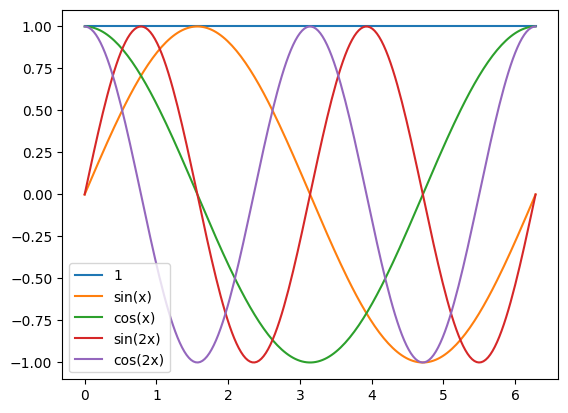

In [10]:
fig, ax = plt.subplots()

ax.plot(x, v0, label="1")
ax.plot(x, v1, label="sin(x)")
ax.plot(x, v2, label="cos(x)")
ax.plot(x, v3, label="sin(2x)")
ax.plot(x, v4, label="cos(2x)")
ax.legend()

### (b)

[[0.005 0.005 0.005 ... 0.005 0.005 0.005]
 [0.005 0.005 0.005 ... 0.005 0.005 0.005]
 [0.005 0.005 0.005 ... 0.005 0.005 0.005]
 ...
 [0.005 0.005 0.005 ... 0.005 0.005 0.005]
 [0.005 0.005 0.005 ... 0.005 0.005 0.005]
 [0.005 0.005 0.005 ... 0.005 0.005 0.005]]


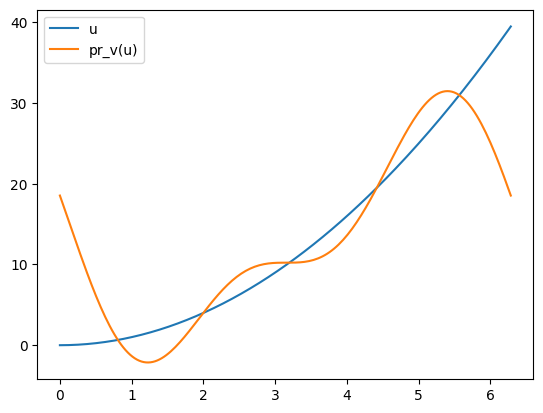

In [11]:
u = (x**2)[:, np.newaxis]
P = (v0 @ v0.T) / (np.linalg.norm(v0)**2) + (v1 @ v1.T) / (np.linalg.norm(v1)**2) + (v2 @ v2.T) / (np.linalg.norm(v2)**2) + (v3 @ v3.T) / (np.linalg.norm(v3)**2) + (v4 @ v4.T) / (np.linalg.norm(v4)**2)

print((1/np.linalg.norm(v0)**2) * v0 @ v0.T)

fig, ax = plt.subplots()
ax.plot(x, u, label="u")
ax.plot(x, P@u, label="pr_v(u)")
ax.legend()

In [12]:
print(f"Den maksimale afvigelse mellem u og dens projektion er {max(abs(u - P@u))}")

Den maksimale afvigelse mellem u og dens projektion er [20.94215416]


### (c)

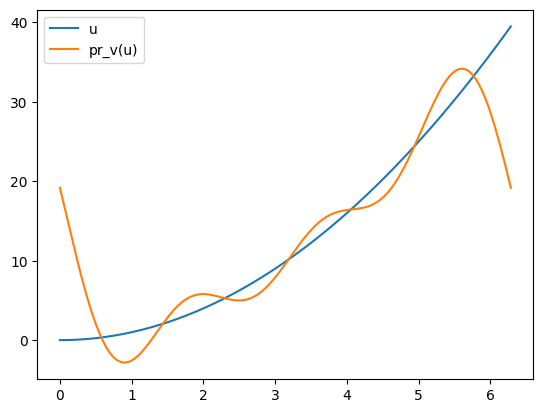

In [13]:
v5 = np.sin(3*x)[:, np.newaxis]
v6 = np.cos(3*x)[:, np.newaxis]

P_ny = P + (v5 @ v5.T) / (np.linalg.norm(v5)**2) + (v6 @ v6.T) / (np.linalg.norm(v6)**2)

fig, ax = plt.subplots()
ax.plot(x, u, label="u")
ax.plot(x, P_ny@u, label="pr_v(u)")
ax.legend()

### (d)

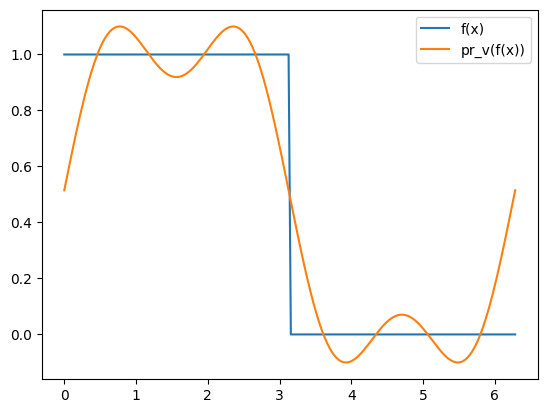

In [14]:
f = np.zeros(u.shape)

for i, val in enumerate(x):
    if val <= np.pi:
        f[i,0] = 1

fig, ax = plt.subplots()
ax.plot(x, f, label="f(x)")
ax.plot(x, P_ny@f, label="pr_v(f(x))")
ax.legend()

### (e)

Man tester ortogonalitet ved at se om det indre produkt er 0. Når der ses på sinus og cosinus er de funktioner som hopper mellem -1 og 1, π/2 eller 90° forskudt af hinanden. Dette vil da sige, at deres værdier hver især vil gå ud med hinanden og ca. give 0. Når der ganges en faktor på ændrer det ikke på denne egenskab, hvilket er derfor alle funktionerne (på nær v0 = 1) næsten er ortogonale.